# Temperatura e interesse por cerveja

Trabalho final de Álgebra Linear.

A ideia é simples: quando faz mais calor, as pessoas pesquisam mais por cerveja no Google? Para tentar responder a gente cruzou duas bases reais — temperatura horária do INMET (estação Mirante de Santana, São Paulo) com o índice semanal do Google Trends para o termo "cerveja" no Brasil — e ajustou uma regressão linear simples.

Não é um modelo para prever consumo. O Trends mede *busca*, não venda. Mas dá pra ver se existe alguma relação entre temperatura e o quanto a palavra é pesquisada.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Coleta dos dados

**INMET.** Arquivo da estação A701 (São Paulo - Mirante) com leituras horárias de 01/01/2026 a 30/04/2026. O CSV vem com 8 linhas de metadados no topo, separador `;`, encoding latin-1 e vírgula como separador decimal — coisas que precisamos passar pro `read_csv`.

**Google Trends.** Série semanal do termo "cerveja" no Brasil para o último ano. O índice vai de 0 a 100 (100 é o pico do período). Cada linha tem a data do domingo de início da semana.

In [2]:
inmet = pd.read_csv(
    'dataset/INMET_SE_SP_A701_SAO PAULO - MIRANTE_01-01-2026_A_30-04-2026.CSV',
    sep=';', skiprows=8, encoding='latin-1', decimal=','
)
inmet['Data'] = pd.to_datetime(inmet['Data'], format='%Y/%m/%d')

# o nome da coluna tem acentos chatos; pegamos pelo prefixo
col_temp = [c for c in inmet.columns if c.startswith('TEMPERATURA DO AR')][0]

inmet[['Data', col_temp]].head()

,Data,"TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)"
0,2026-01-01,25.1
1,2026-01-01,24.4
2,2026-01-01,24.6
3,2026-01-01,24.7
4,2026-01-01,24.4


In [3]:
trends = pd.read_csv('dataset/time_series_BR_20250519-1902_20260519-1902.csv')
trends['Time'] = pd.to_datetime(trends['Time'])
trends = trends.rename(columns={'Time': 'semana', 'cerveja': 'interesse'})

trends.head()

,semana,interesse
0,2025-05-18,40
1,2025-05-25,40
2,2025-06-01,42
3,2025-06-08,41
4,2025-06-15,45


## Tratamento dos dados

As granularidades são diferentes — INMET é horário, Trends é semanal. Pra cruzar precisamos agregar a temperatura por semana e que o rótulo da semana case com o do Trends (domingo).

Em pandas, `to_period('W-SAT')` gera períodos que terminam no sábado, e o `start_time` deles cai no domingo anterior, que é exatamente o rótulo do Trends. A gente testou `W-SUN` antes mas não casou (ele rotula na segunda).

Também filtramos semanas com poucos pontos — a primeira semana do recorte do INMET só tem 1 dia (01/01) e a última tem 5, então ficam fora.

In [4]:
inmet['semana'] = inmet['Data'].dt.to_period('W-SAT').dt.start_time

temp_semanal = (
    inmet.groupby('semana')[col_temp]
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'temperatura', 'count': 'n_horas'})
    .reset_index()
)

# manter so semanas com pelo menos 100 horas de leitura (de 168 possiveis)
temp_semanal = temp_semanal[temp_semanal['n_horas'] >= 100][['semana', 'temperatura']]

dados = temp_semanal.merge(trends, on='semana').reset_index(drop=True)
print(f'{len(dados)} semanas com temperatura e interesse cruzados')
dados

17 semanas com temperatura e interesse cruzados


,semana,temperatura,interesse
0,2026-01-04,22.800599,57
1,2026-01-11,24.092262,59
2,2026-01-18,19.750898,57
3,2026-01-25,22.232934,54
4,2026-02-01,22.919643,52
5,2026-02-08,23.286310,59
6,2026-02-15,24.758333,60
7,2026-02-22,21.950000,46
8,2026-03-01,21.142262,51
9,2026-03-08,20.533333,47


## Visualização dos dados

Primeiro a evolução das duas séries ao longo das semanas, depois um scatter de uma contra a outra.

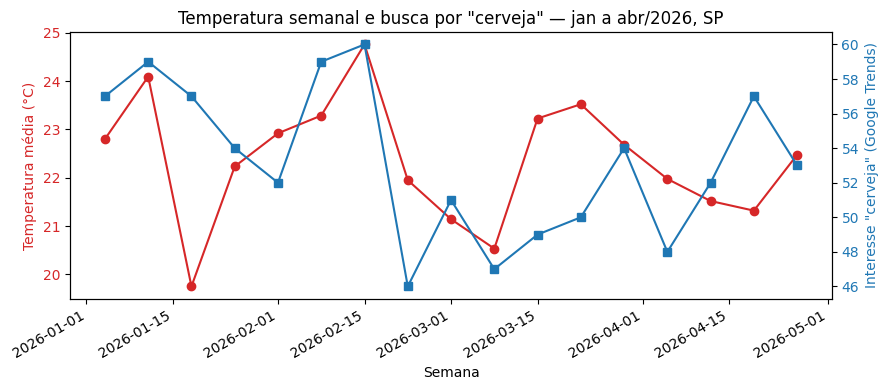

In [5]:
fig, ax1 = plt.subplots(figsize=(9, 4))
ax2 = ax1.twinx()

ax1.plot(dados['semana'], dados['temperatura'], 'o-', color='tab:red')
ax2.plot(dados['semana'], dados['interesse'], 's-', color='tab:blue')

ax1.set_xlabel('Semana')
ax1.set_ylabel('Temperatura média (°C)', color='tab:red')
ax2.set_ylabel('Interesse "cerveja" (Google Trends)', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:blue')

fig.autofmt_xdate()
plt.title('Temperatura semanal e busca por "cerveja" — jan a abr/2026, SP')
plt.tight_layout()
plt.show()

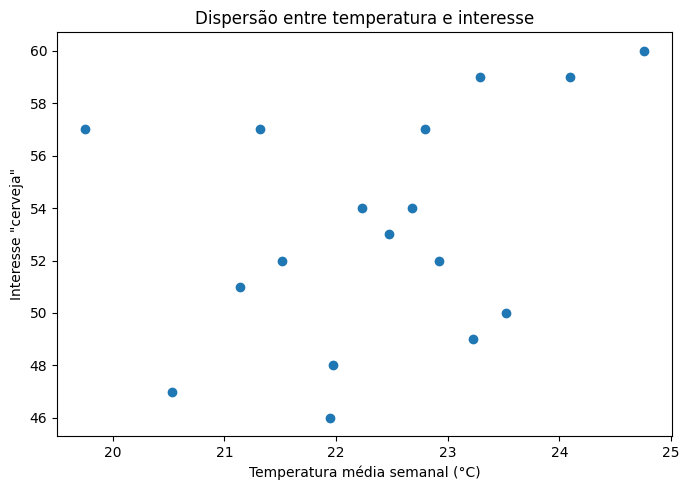

In [6]:
plt.figure(figsize=(7, 5))
plt.scatter(dados['temperatura'], dados['interesse'])
plt.xlabel('Temperatura média semanal (°C)')
plt.ylabel('Interesse "cerveja"')
plt.title('Dispersão entre temperatura e interesse')
plt.tight_layout()
plt.show()

## Modelagem matemática

Assumimos uma relação linear entre temperatura e interesse:

$$ y = w_0 + w_1\, x $$

No nosso caso $x$ é a temperatura média semanal (°C) e $y$ é o índice do Trends. O $w_1$ diz quantos pontos do índice variam para cada grau a mais; o $w_0$ é o intercepto.

Como temos 17 observações, dá pra escrever isso de forma matricial empilhando as equações:

$$
\underbrace{\begin{pmatrix} 1 & x_1 \\ 1 & x_2 \\ \vdots & \vdots \\ 1 & x_{17} \end{pmatrix}}_{\mathbf{X}}
\underbrace{\begin{pmatrix} w_0 \\ w_1 \end{pmatrix}}_{\mathbf{w}}
\;\approx\;
\underbrace{\begin{pmatrix} y_1 \\ y_2 \\ \vdots \\ y_{17} \end{pmatrix}}_{\mathbf{y}}
$$

Ou seja, $\mathbf{X}\mathbf{w} \approx \mathbf{y}$. O sistema não tem solução exata (os pontos não caem todos numa reta), então procuramos o $\mathbf{w}$ que minimiza $\|\mathbf{X}\mathbf{w} - \mathbf{y}\|^2$. Esse é o problema de mínimos quadrados, e é o que a função `np.linalg.lstsq` resolve.

In [7]:
x = dados['temperatura'].values
y = dados['interesse'].values

X = np.column_stack([np.ones(len(x)), x])
w, *_ = np.linalg.lstsq(X, y, rcond=None)
w0, w1 = w

y_pred = w0 + w1 * x
r2 = 1 - ((y - y_pred) ** 2).sum() / ((y - y.mean()) ** 2).sum()

print(f'w0 (intercepto): {w0:.2f}')
print(f'w1 (inclinação): {w1:.2f}')
print(f'R²: {r2:.3f}')

w0 (intercepto): 26.14
w1 (inclinação): 1.21
R²: 0.123


## Resultados

O modelo ajustado ficou:

$$ \hat{y} = 26{,}14 + 1{,}21\, x $$

Cada +1 °C na temperatura média da semana está associado a um aumento de cerca de 1,2 ponto no índice. O sinal é o esperado — calor parece sim puxar buscas por cerveja pra cima.

Mas o R² é baixo, em torno de 0,12. Quer dizer que a temperatura explica só uns 12% da variação do índice. Os outros 88% vêm de coisas que o modelo não vê: fim de semana, feriado, eventos esportivos, promoção, calendário em geral. A correlação de Pearson entre as duas séries é cerca de 0,35, o que confirma uma relação positiva mas fraca.

A reta sobreposta ao scatter mostra isso:

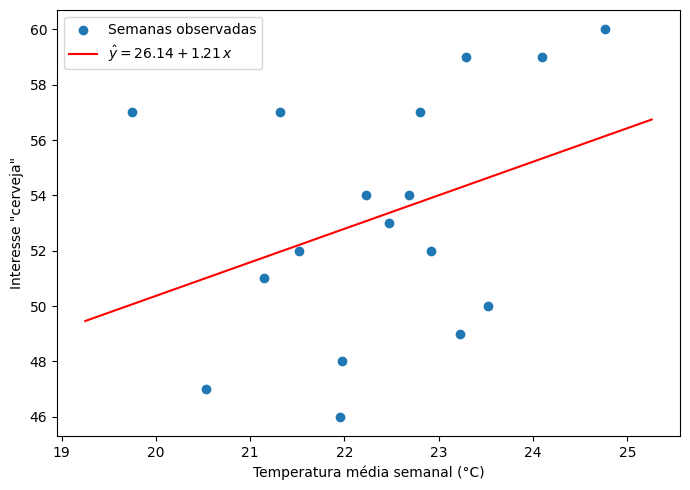

In [8]:
plt.figure(figsize=(7, 5))
plt.scatter(x, y, label='Semanas observadas')
xx = np.linspace(x.min() - 0.5, x.max() + 0.5, 50)
plt.plot(xx, w0 + w1 * xx, color='red',
         label=rf'$\hat{{y}} = {w0:.2f} + {w1:.2f}\,x$')
plt.xlabel('Temperatura média semanal (°C)')
plt.ylabel('Interesse "cerveja"')
plt.legend()
plt.tight_layout()
plt.show()

## Limitações

- **O Trends mede interesse, não consumo.** Pesquisar "cerveja" pode ser pra ver promoção, marca, receita, harmonização — não necessariamente pra comprar.
- **Janela curta.** Só 17 semanas, todas concentradas em verão/outono de São Paulo. A faixa de temperatura média também não foi grande (de ~20 a 25 °C).
- **Feriados e eventos pesam.** Olhando a série completa do Trends, o pico do ano foi a semana do Natal (21/12/2025), bem fora da janela do INMET. Isso não tem a ver com calor.
- **Relação linear é uma simplificação.** Pode haver efeito não-linear (saturação em temperaturas muito altas, por exemplo), mas com tão poucos pontos não dá pra testar.
- **Só uma cidade.** A temperatura é de São Paulo (Mirante), o Trends é do Brasil inteiro. O ideal seria comparar com uma série de Trends restrita a SP, ou olhar várias capitais.

## Conclusão

Existe sim uma relação positiva entre a temperatura média semanal em SP e o quanto se pesquisa por "cerveja" no Google, mas ela é fraca — o R² ficou em 0,12. O exercício serviu mais pra mostrar como uma regressão linear simples se monta: escrever o problema em forma matricial $\mathbf{X}\mathbf{w} \approx \mathbf{y}$, resolver por mínimos quadrados e interpretar os coeficientes. Com mais meses de dados, ou trocando o termo de busca, dá pra estender.